In [1]:
from pathlib import Path
import os

import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import URL, create_engine, text

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

PROJECT_ROOT = Path.cwd().parent
ENV_PATH = PROJECT_ROOT / ".env"

load_dotenv(ENV_PATH)

db_url = URL.create(
    drivername="postgresql+psycopg",
    username=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    host=os.getenv("DB_HOST"),
    port=int(os.getenv("DB_PORT")),
    database=os.getenv("DB_NAME"),
)

engine = create_engine(db_url)

job_postings = pd.read_sql_query(
    sql=text(
        """
        SELECT
            job_id,
            company_id,
            job_title_short,
            job_country,
            job_via,
            job_posted_date
        FROM data_jobs.job_postings_fact
        """
    ),
    con=engine,
)

companies = pd.read_sql_query(
    sql=text(
        """
        SELECT
            company_id,
            name AS company_name
        FROM data_jobs.company_dim
        """
    ),
    con=engine,
)

print("Loaded DataFrames:")
print(f"- job_postings: {job_postings.shape[0]:,} rows × {job_postings.shape[1]} columns")
print(f"- companies: {companies.shape[0]:,} rows × {companies.shape[1]} columns")

Loaded DataFrames:
- job_postings: 478,895 rows × 6 columns
- companies: 98,372 rows × 2 columns


In [2]:
source_profile = (
    job_postings
    .assign(job_via=job_postings["job_via"].fillna("Missing"))
    .groupby(
        "job_via",
        as_index=False,
    )
    .agg(
        posting_count=("job_id", "nunique"),
        unique_companies=("company_id", "nunique"),
        unique_countries=("job_country", "nunique"),
    )
)

source_profile["posting_share_pct"] = (
    source_profile["posting_count"]
    / len(job_postings)
    * 100
).round(2)

source_profile = source_profile.sort_values(
    by="posting_count",
    ascending=False,
).reset_index(drop=True)

source_concentration_summary = pd.DataFrame(
    {
        "metric": [
            "total_postings",
            "unique_job_sources",
            "missing_job_source_count",
            "missing_job_source_pct",
            "top_1_source_postings",
            "top_1_source_share_pct",
            "top_5_sources_postings",
            "top_5_sources_share_pct",
            "top_10_sources_postings",
            "top_10_sources_share_pct",
        ],
        "value": [
            len(job_postings),
            job_postings["job_via"].nunique(dropna=True),
            job_postings["job_via"].isna().sum(),
            round(
                job_postings["job_via"].isna().mean() * 100,
                2,
            ),
            source_profile["posting_count"].head(1).sum(),
            round(
                source_profile["posting_count"].head(1).sum()
                / len(job_postings)
                * 100,
                2,
            ),
            source_profile["posting_count"].head(5).sum(),
            round(
                source_profile["posting_count"].head(5).sum()
                / len(job_postings)
                * 100,
                2,
            ),
            source_profile["posting_count"].head(10).sum(),
            round(
                source_profile["posting_count"].head(10).sum()
                / len(job_postings)
                * 100,
                2,
            ),
        ],
    }
)

display(source_concentration_summary)

display(source_profile.head(30))

,metric,value
0,total_postings,"478,895.00"
1,unique_job_sources,"7,859.00"
2,missing_job_source_count,6.00
3,missing_job_source_pct,0.00
4,top_1_source_postings,"149,955.00"
5,top_1_source_share_pct,31.31
6,top_5_sources_postings,"253,624.00"
7,top_5_sources_share_pct,52.96
8,top_10_sources_postings,"290,538.00"
9,top_10_sources_share_pct,60.67


,job_via,posting_count,unique_companies,unique_countries,posting_share_pct
0,via LinkedIn,149955,34814,90,31.31
1,via BeBee,40663,13843,63,8.49
2,via Indeed,29463,13238,54,6.15
3,LinkedIn,22340,8285,83,4.66
4,BeBee,11203,4717,35,2.34
5,via ZipRecruiter,11164,3913,8,2.33
6,via Jooble,8983,4307,57,1.88
7,via GrabJobs,6366,3918,46,1.33
8,via Recruit.net,5570,2543,73,1.16
9,Indeed,4831,2721,54,1.01


In [3]:
company_postings = (
    job_postings
    .merge(
        companies,
        on="company_id",
        how="left",
        validate="many_to_one",
    )
)

company_postings["company_name"] = (
    company_postings["company_name"]
    .fillna("Missing company name")
)

company_profile = (
    company_postings
    .groupby(
        [
            "company_id",
            "company_name",
        ],
        as_index=False,
    )
    .agg(
        posting_count=("job_id", "nunique"),
        unique_sources=("job_via", "nunique"),
        unique_countries=("job_country", "nunique"),
        unique_job_roles=("job_title_short", "nunique"),
    )
)

company_profile["posting_share_pct"] = (
    company_profile["posting_count"]
    / len(job_postings)
    * 100
).round(4)

company_profile = company_profile.sort_values(
    by=[
        "posting_count",
        "company_name",
    ],
    ascending=[
        False,
        True,
    ],
).reset_index(drop=True)

company_join_summary = pd.DataFrame(
    {
        "metric": [
            "job_postings_before_company_join",
            "job_postings_after_company_join",
            "rows_lost_after_company_join",
            "unique_company_ids_in_postings",
            "unique_company_ids_after_join",
            "missing_company_names_after_join",
            "missing_company_names_after_join_pct",
            "top_1_company_postings",
            "top_1_company_share_pct",
            "top_10_companies_postings",
            "top_10_companies_share_pct",
        ],
        "value": [
            len(job_postings),
            len(company_postings),
            len(job_postings) - len(company_postings),
            job_postings["company_id"].nunique(),
            company_postings["company_id"].nunique(),
            company_postings["company_name"].eq(
                "Missing company name"
            ).sum(),
            round(
                company_postings["company_name"].eq(
                    "Missing company name"
                ).mean()
                * 100,
                2,
            ),
            company_profile["posting_count"].head(1).sum(),
            round(
                company_profile["posting_count"].head(1).sum()
                / len(job_postings)
                * 100,
                2,
            ),
            company_profile["posting_count"].head(10).sum(),
            round(
                company_profile["posting_count"].head(10).sum()
                / len(job_postings)
                * 100,
                2,
            ),
        ],
    }
)

display(company_join_summary)

display(company_profile.head(30))

,metric,value
0,job_postings_before_company_join,"478,895.00"
1,job_postings_after_company_join,"478,895.00"
2,rows_lost_after_company_join,0.00
3,unique_company_ids_in_postings,"98,372.00"
4,unique_company_ids_after_join,"98,372.00"
5,missing_company_names_after_join,0.00
6,missing_company_names_after_join_pct,0.00
7,top_1_company_postings,"3,611.00"
8,top_1_company_share_pct,0.75
9,top_10_companies_postings,"20,217.00"


,company_id,company_name,posting_count,unique_sources,unique_countries,unique_job_roles,posting_share_pct
0,1145,Dice,3611,18,6,10,0.75
1,506,Listopro,2963,16,9,9,0.62
2,3188,Capital One,2480,133,9,10,0.52
3,964,Insight Global,1704,63,13,10,0.36
4,439,Walmart,1646,93,6,10,0.34
5,679,OpenClassrooms,1618,27,4,7,0.34
6,4,VirtualVocations,1617,7,4,10,0.34
7,391,ClickJobs.io,1579,10,7,10,0.33
8,10044,CareerBuilder,1546,6,3,10,0.32
9,295,Amazon,1453,86,44,10,0.30


In [4]:
def calculate_hhi(count_series):
    shares = count_series / count_series.sum()
    return (shares.pow(2).sum() * 10_000)

source_hhi = calculate_hhi(source_profile["posting_count"])
company_hhi = calculate_hhi(company_profile["posting_count"])

source_company_concentration_metrics = pd.DataFrame(
    {
        "entity": [
            "Job-posting sources",
            "Companies",
        ],
        "unique_entities": [
            len(source_profile),
            len(company_profile),
        ],
        "top_1_share_pct": [
            round(
                source_profile["posting_count"].head(1).sum()
                / len(job_postings)
                * 100,
                2,
            ),
            round(
                company_profile["posting_count"].head(1).sum()
                / len(job_postings)
                * 100,
                2,
            ),
        ],
        "top_5_share_pct": [
            round(
                source_profile["posting_count"].head(5).sum()
                / len(job_postings)
                * 100,
                2,
            ),
            round(
                company_profile["posting_count"].head(5).sum()
                / len(job_postings)
                * 100,
                2,
            ),
        ],
        "top_10_share_pct": [
            round(
                source_profile["posting_count"].head(10).sum()
                / len(job_postings)
                * 100,
                2,
            ),
            round(
                company_profile["posting_count"].head(10).sum()
                / len(job_postings)
                * 100,
                2,
            ),
        ],
        "hhi": [
            round(source_hhi, 2),
            round(company_hhi, 2),
        ],
    }
)

display(source_company_concentration_metrics)

,entity,unique_entities,top_1_share_pct,top_5_share_pct,top_10_share_pct,hhi
0,Job-posting sources,7860,31.31,52.96,60.67,"1,139.95"
1,Companies,98372,0.75,2.59,4.22,4.17


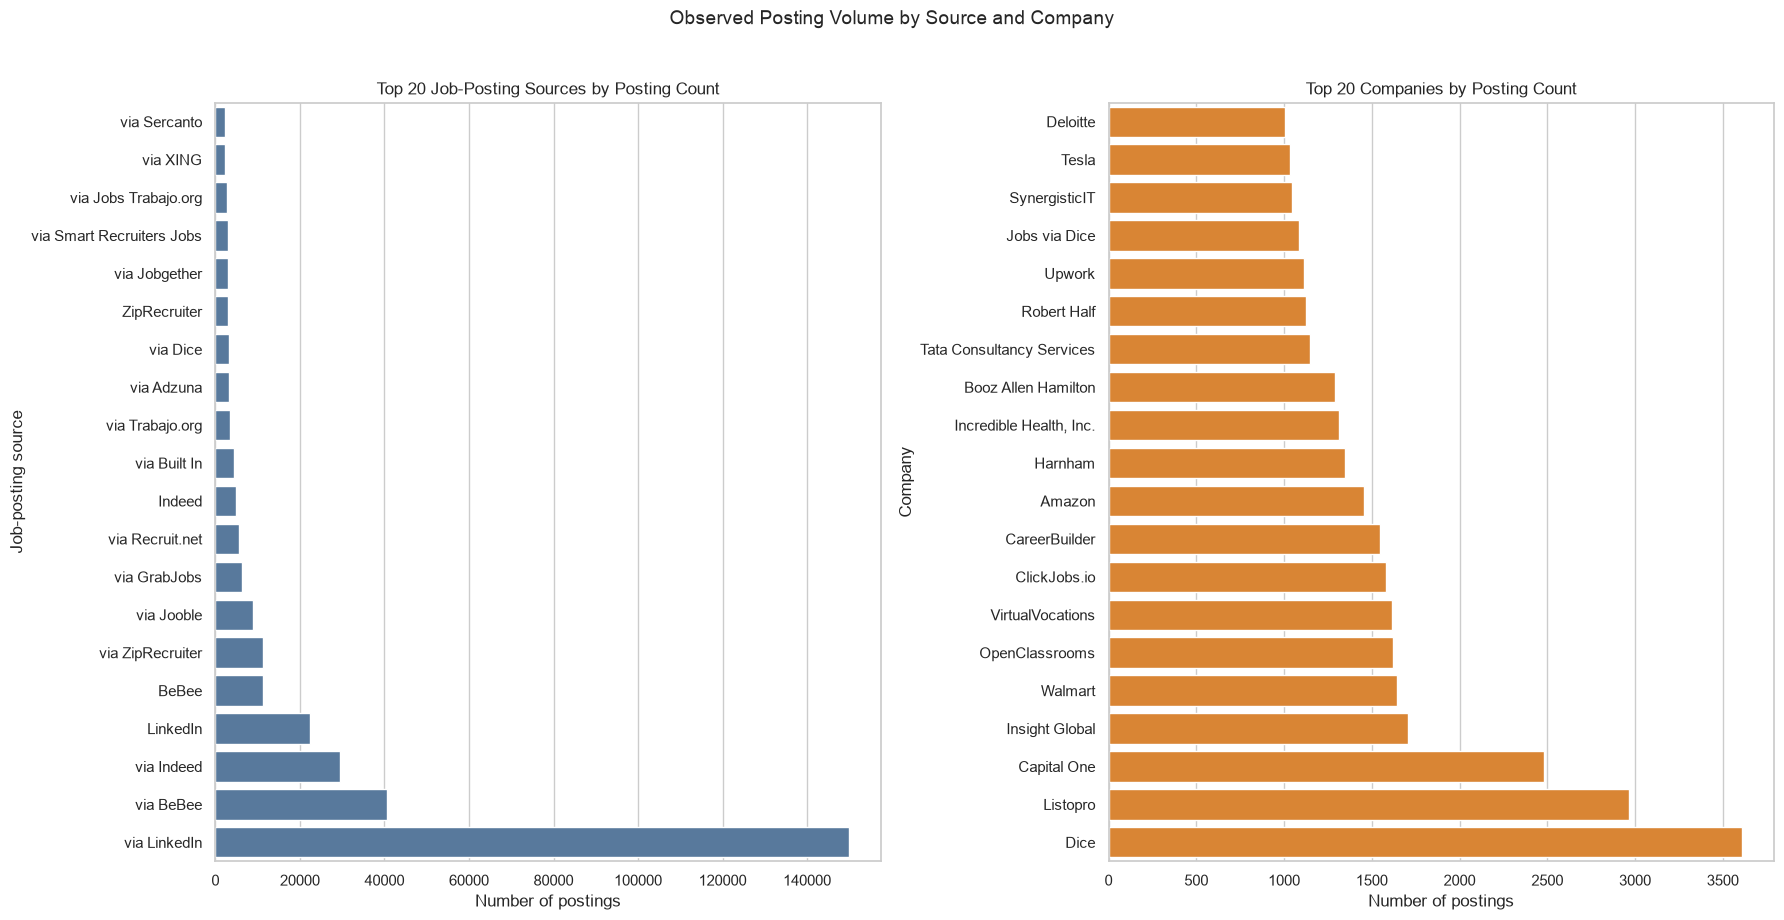

In [5]:
TOP_N_SOURCES = 20
TOP_N_COMPANIES = 20

top_sources_plot = (
    source_profile
    .head(TOP_N_SOURCES)
    .sort_values(
        by="posting_count",
        ascending=True,
    )
)

top_companies_plot = (
    company_profile
    .head(TOP_N_COMPANIES)
    .sort_values(
        by="posting_count",
        ascending=True,
    )
)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(18, 9),
)

sns.barplot(
    data=top_sources_plot,
    x="posting_count",
    y="job_via",
    ax=axes[0],
    color="#4C78A8",
)

axes[0].set_title(
    f"Top {TOP_N_SOURCES} Job-Posting Sources by Posting Count"
)
axes[0].set_xlabel("Number of postings")
axes[0].set_ylabel("Job-posting source")

sns.barplot(
    data=top_companies_plot,
    x="posting_count",
    y="company_name",
    ax=axes[1],
    color="#F58518",
)

axes[1].set_title(
    f"Top {TOP_N_COMPANIES} Companies by Posting Count"
)
axes[1].set_xlabel("Number of postings")
axes[1].set_ylabel("Company")

fig.suptitle(
    "Observed Posting Volume by Source and Company",
    fontsize=14,
    y=1.02,
)

plt.tight_layout()
plt.show()

In [6]:
source_company_summary = pd.DataFrame(
    {
        "area": [
            "Analysis population",
            "Source availability",
            "Source concentration",
            "Company mapping",
            "Company concentration",
            "Interpretation of source counts",
            "Interpretation of company counts",
            "Dataset representation",
        ],
        "observation": [
            (
                f"The analysis includes {len(job_postings):,} source job postings."
            ),
            (
                f"job_via is missing for "
                f"{job_postings['job_via'].isna().sum():,} postings "
                f"({job_postings['job_via'].isna().mean() * 100:.2f}%)."
            ),
            (
                f"The top 10 sources account for "
                f"{source_profile['posting_count'].head(10).sum() / len(job_postings) * 100:.2f}% "
                f"of observed postings; source HHI is {source_hhi:.2f}."
            ),
            (
                f"Company metadata is available after the join for "
                f"{(~company_postings['company_name'].eq('Missing company name')).sum():,} postings "
                f"({(~company_postings['company_name'].eq('Missing company name')).mean() * 100:.2f}%)."
            ),
            (
                f"The top 10 companies account for "
                f"{company_profile['posting_count'].head(10).sum() / len(job_postings) * 100:.2f}% "
                f"of observed postings; company HHI is {company_hhi:.2f}."
            ),
            (
                "A high posting count for a source may reflect aggregation, scraping coverage, "
                "or publishing-channel behaviour rather than the source's market share."
            ),
            (
                "A high posting count for a company reflects observed postings in this dataset "
                "and does not directly measure total hiring, headcount, or revenue."
            ),
            (
                "Results describe the dataset's included sources and should not be interpreted "
                "as a complete census of the global job-posting market."
            ),
        ],
        "analysis_implication": [
            (
                "All source and company rankings are based on the full retained source dataset."
            ),
            (
                "Treat missing source records as a small documented limitation."
            ),
            (
                "Report concentration metrics with rankings to contextualise source dominance."
            ),
            (
                "Use company rankings only where company metadata is successfully mapped."
            ),
            (
                "Use concentration metrics as descriptive indicators, not evidence of market power."
            ),
            (
                "Describe sources as dominant within the observed dataset, not universally dominant platforms."
            ),
            (
                "Describe companies as frequent posters in the observed dataset, not necessarily the largest employers."
            ),
            (
                "Avoid generalising source and company results to the entire global labour market."
            ),
        ],
    }
)

display(source_company_summary)

,area,observation,analysis_implication
0,Analysis population,"The analysis includes 478,895 source job posti...",All source and company rankings are based on t...
1,Source availability,job_via is missing for 6 postings (0.00%).,Treat missing source records as a small docume...
2,Source concentration,The top 10 sources account for 60.67% of obser...,Report concentration metrics with rankings to ...
3,Company mapping,Company metadata is available after the join f...,Use company rankings only where company metada...
4,Company concentration,The top 10 companies account for 4.22% of obse...,Use concentration metrics as descriptive indic...
5,Interpretation of source counts,A high posting count for a source may reflect ...,Describe sources as dominant within the observ...
6,Interpretation of company counts,A high posting count for a company reflects ob...,Describe companies as frequent posters in the ...
7,Dataset representation,Results describe the dataset's included source...,Avoid generalising source and company results ...


In [7]:
source_company_final_results = {
    "analysis_population": {
        "total_source_postings": int(len(job_postings)),
        "unique_job_sources": int(len(source_profile)),
        "unique_companies": int(len(company_profile)),
    },
    "source_concentration": {
        "top_1_share_pct": float(
            round(
                source_profile["posting_count"].head(1).sum()
                / len(job_postings)
                * 100,
                2,
            )
        ),
        "top_5_share_pct": float(
            round(
                source_profile["posting_count"].head(5).sum()
                / len(job_postings)
                * 100,
                2,
            )
        ),
        "top_10_share_pct": float(
            round(
                source_profile["posting_count"].head(10).sum()
                / len(job_postings)
                * 100,
                2,
            )
        ),
        "hhi": float(round(source_hhi, 2)),
    },
    "company_concentration": {
        "top_1_share_pct": float(
            round(
                company_profile["posting_count"].head(1).sum()
                / len(job_postings)
                * 100,
                2,
            )
        ),
        "top_5_share_pct": float(
            round(
                company_profile["posting_count"].head(5).sum()
                / len(job_postings)
                * 100,
                2,
            )
        ),
        "top_10_share_pct": float(
            round(
                company_profile["posting_count"].head(10).sum()
                / len(job_postings)
                * 100,
                2,
            )
        ),
        "hhi": float(round(company_hhi, 2)),
    },
    "top_10_sources": (
        source_profile[
            [
                "job_via",
                "posting_count",
                "posting_share_pct",
                "unique_companies",
                "unique_countries",
            ]
        ]
        .head(10)
        .to_dict(orient="records")
    ),
    "top_10_companies": (
        company_profile[
            [
                "company_id",
                "company_name",
                "posting_count",
                "posting_share_pct",
                "unique_sources",
                "unique_countries",
                "unique_job_roles",
            ]
        ]
        .head(10)
        .to_dict(orient="records")
    ),
}

source_company_final_results

{'analysis_population': {'total_source_postings': 478895,
  'unique_job_sources': 7860,
  'unique_companies': 98372},
 'source_concentration': {'top_1_share_pct': 31.31,
  'top_5_share_pct': 52.96,
  'top_10_share_pct': 60.67,
  'hhi': 1139.95},
 'company_concentration': {'top_1_share_pct': 0.75,
  'top_5_share_pct': 2.59,
  'top_10_share_pct': 4.22,
  'hhi': 4.17},
 'top_10_sources': [{'job_via': 'via LinkedIn',
   'posting_count': 149955,
   'posting_share_pct': 31.31,
   'unique_companies': 34814,
   'unique_countries': 90},
  {'job_via': 'via BeBee',
   'posting_count': 40663,
   'posting_share_pct': 8.49,
   'unique_companies': 13843,
   'unique_countries': 63},
  {'job_via': 'via Indeed',
   'posting_count': 29463,
   'posting_share_pct': 6.15,
   'unique_companies': 13238,
   'unique_countries': 54},
  {'job_via': 'LinkedIn',
   'posting_count': 22340,
   'posting_share_pct': 4.66,
   'unique_companies': 8285,
   'unique_countries': 83},
  {'job_via': 'BeBee',
   'posting_count'